In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de modelos y métricas
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, roc_auc_score,
                             precision_score, recall_score, silhouette_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Monta drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import io

# Configura ruta y carga datos con manejo de errores de formato
ruta_base = '/content/drive/MyDrive/Proyecto_Diabetes_Data/'

archivos = {
    'antropometria': 'Cuestionario de antropometría y tensión arterial_2024.csv.zip',
    'salud_adultos': 'Cuestionario de salud de adultos (20 años o más).zip',
    'alimentos': 'Frecuencia de consumo de alimentos de adolescentes y adultos (12 años o más).zip',
    'residentes': 'Información sobre los residentes.zip',
    'hemoglobina': 'sangre_hemoglobina_ensanut2024_w.csv'
}

def cargar_datos_robusto(nombre_archivo):
    ruta_completa = os.path.join(ruta_base, nombre_archivo)

    # Usa try para capturar errores de lectura
    try:
        if nombre_archivo.endswith('.zip'):
            with zipfile.ZipFile(ruta_completa, 'r') as z:
                archivo_interno = z.namelist()[0]
                with z.open(archivo_interno) as f:
                    # Lee el contenido para detectar si es realmente un CSV o un Excel disfrazado
                    contenido = f.read()
                    # Si detecta la firma de un archivo ZIP/Excel (PK...), lo trata como Excel
                    if contenido.startswith(b'PK'):
                        df = pd.read_excel(io.BytesIO(contenido))
                    else:
                        df = pd.read_csv(io.BytesIO(contenido), encoding='latin-1', sep=None, engine='python', on_bad_lines='skip')
        else:
            df = pd.read_csv(ruta_completa, encoding='latin-1', sep=None, engine='python', on_bad_lines='skip')

        # Limpia nombres de columnas: mayúsculas, quita espacios y el BOM
        df.columns = df.columns.str.strip().str.upper().str.replace('ï»¿', '').str.replace('\n', '')
        return df
    except Exception as e:
        print(f"Error al procesar {nombre_archivo}: {e}")
        return pd.DataFrame()

# Ejecuta la carga
df_antropo = cargar_datos_robusto(archivos['antropometria'])
df_salud = cargar_datos_robusto(archivos['salud_adultos'])
df_alimentos = cargar_datos_robusto(archivos['alimentos'])
df_residentes = cargar_datos_robusto(archivos['residentes'])
df_hemo = cargar_datos_robusto(archivos['hemoglobina'])

print("--- Resumen de Carga ---")
print(f"Antropometría: {df_antropo.shape}")
print(f"Salud: {df_salud.shape}")
print(f"Alimentos: {df_alimentos.shape}")
print(f"Residentes: {df_residentes.shape}")
print(f"Hemoglobina: {df_hemo.shape}")

--- Resumen de Carga ---
Antropometría: (17597, 100)
Salud: (857, 5)
Alimentos: (3894, 57)
Residentes: (36021, 6)
Hemoglobina: (9401, 87)


In [ ]:
# Reparación de Salud y Unión Maestra
def limpiar_df_salud(df):
    # Si las columnas son 'UNNAMED', es que el encabezado está más abajo
    # Busca la fila que contiene 'UPM' o 'FOLIO_I'
    for i in range(len(df)):
        fila = df.iloc[i].astype(str).str.upper()
        if 'UPM' in fila.values or 'FOLIO_I' in fila.values:
            # Reasigna columnas y recorta el dataframe
            df.columns = df.iloc[i].str.strip().str.upper()
            df = df.iloc[i+1:].reset_index(drop=True)
            break
    return df

# Aplica limpieza específica a Salud
df_salud = limpiar_df_salud(df_salud)

# Elimina columnas basura en Antropometría (como Ï»¿FOLIO_I)
if 'Ï»¿FOLIO_I' in df_antropo.columns:
    df_antropo = df_antropo.drop(columns=['Ï»¿FOLIO_I'])

# Función para estandarizar el FOLIO_I
def estandarizar_folio(df):
    # Si tiene FOLIO_I, lo usamos. Si no, lo construimos.
    if 'FOLIO_I' in df.columns:
        df['FOLIO_I'] = df['FOLIO_I'].astype(str).str.strip()
    elif all(k in df.columns for k in ['UPM', 'VIV_SEL', 'NUM_REN']):
        # Crea FOLIO_I uniendo las partes (UPM + VIV_SEL + NUM_REN)
        df['FOLIO_I'] = (df['UPM'].astype(str) +
                         df['VIV_SEL'].astype(str).str.zfill(2) +
                         df['NUM_REN'].astype(str).zfill(2))
    return df

# Estandariza todas
df_salud = estandarizar_folio(df_salud)
df_antropo = estandarizar_folio(df_antropo)
df_alimentos = estandarizar_folio(df_alimentos)
df_hemo = estandarizar_folio(df_hemo)

df_salud = df_salud.loc[:, df_salud.columns.notna()]

# Intenta la unión
try:
    # Unión Base: Salud + Antropometría
    df_unido = pd.merge(df_salud, df_antropo, on='FOLIO_I', how='inner', suffixes=('', '_ANTRO'))

    # Agrega Alimentos y Hemoglobina
    df_unido = pd.merge(df_unido, df_alimentos, on='FOLIO_I', how='left', suffixes=('', '_ALIM'))
    df_unido = pd.merge(df_unido, df_hemo, on='FOLIO_I', how='left', suffixes=('', '_HEMO'))

    print("¡Unión exitosa!")
    print(f"Registros finales: {len(df_unido)}")
    print("Columnas clave encontradas:", [c for c in ['UPM', 'VIV_SEL', 'H0301', 'AN08_1'] if c in df_unido.columns])
except Exception as e:
    print(f"Error en la unión: {e}")
    print("Columnas detectadas en Salud ahora:", df_salud.columns.tolist())

Error en la unión: 'FOLIO_I'
Columnas detectadas en Salud ahora: ['FOLIO_I', 'FOLIO', 'NOMINAL']


In [ ]:
# Identifica el archivo de datos por su tamaño y carga
import zipfile
import os

def carga_base_real_pesada(nombre_zip):
    ruta = os.path.join(ruta_base, nombre_zip)
    with zipfile.ZipFile(ruta, 'r') as z:
        # Obtiene lista de archivos con sus detalles
        info_archivos = z.infolist()

        # Muestra qué hay dentro para que Paula vea
        print(f"Contenido de {nombre_zip}:")
        for info in info_archivos:
            print(f"- {info.filename} ({info.file_size / 1024:.2f} KB)")

        # Ordena por tamaño (el más grande primero)
        info_archivos.sort(key=lambda x: x.file_size, reverse=True)

        # El archivo más grande es la base de datos
        archivo_datos = info_archivos[0].filename
        print(f"-> Seleccionado por tamaño: {archivo_datos}")

        with z.open(archivo_datos) as f:
            if archivo_datos.lower().endswith('.csv'):
                return pd.read_csv(f, encoding='latin-1', sep=None, engine='python', on_bad_lines='skip')
            else:
                return pd.read_excel(f)

# Re-carga Salud usando el archivo más pesado del ZIP
df_salud = carga_base_real_pesada(archivos['salud_adultos'])

# Limpia columnas de forma agresiva
df_salud.columns = df_salud.columns.str.strip().str.upper().str.replace('Ï»¿', '')
df_antropo.columns = df_antropo.columns.str.strip().str.upper().str.replace('Ï»¿', '')

# Intenta unión por FOLIO_I
if 'FOLIO_I' in df_salud.columns and 'FOLIO_I' in df_antropo.columns:
    df_salud['FOLIO_I'] = df_salud['FOLIO_I'].astype(str).str.strip()
    df_antropo['FOLIO_I'] = df_antropo['FOLIO_I'].astype(str).str.strip()

    df_unido = pd.merge(df_salud, df_antropo, on='FOLIO_I', how='inner', suffixes=('', '_ANTRO'))

    print("\n--- Diagnóstico ---")
    print(f"Registros unidos con éxito: {len(df_unido)}")
    if len(df_unido) > 0:
        print("LOGRADO")
else:
    print("\nError: FOLIO_I no está en las columnas.")
    print(f"Columnas Salud detectadas: {df_salud.columns.tolist()[:5]}")

Contenido de Cuestionario de salud de adultos (20 años o más).zip:
- adultos_ensanut2024_w.Catálogo.xlsx (241.75 KB)
-> Seleccionado por tamaño: adultos_ensanut2024_w.Catálogo.xlsx

Error: FOLIO_I no está en las columnas.
Columnas Salud detectadas: ['UNNAMED: 0', 'UNNAMED: 1', 'UNNAMED: 2', 'UNNAMED: 3', 'UNNAMED: 4']


In [ ]:
# Lista todas las columnas para identificar variables de salud y antropometría
# Limpia los nombres de columnas de antropometría primero
df_antropo.columns = [str(c).replace('Ï»¿', '').strip().upper() for c in df_antropo.columns]

print("--- Buscador de Variables en Antropometría ---")
# Filtra columnas que empiecen con 'AN' (Antropometría) o 'H' (Salud) o tengan 'IMC'
columnas_interes = [c for c in df_antropo.columns if c.startswith('AN') or c.startswith('H') or 'IMC' in c]

if columnas_interes:
    print(f"Columnas detectadas ({len(columnas_interes)}):")
    print(columnas_interes)
else:
    print("No se detectaron columnas con prefijos estándar. Listando las primeras 50 columnas totales:")
    print(df_antropo.columns.tolist()[:50])

# Muestra las primeras 3 filas para ver el tipo de datos que contienen
print("\nVista previa de los datos:")
display(df_antropo[columnas_interes].head(3) if columnas_interes else df_antropo.head(3))

--- Buscador de Variables en Antropometría ---
Columnas detectadas (55):
['HORA_INI_1', 'HORA_FIN_1', 'HORA_INI_2', 'HORA_FIN_2', 'HORA_INI_3', 'HORA_FIN_3', 'HORA_INI_4', 'HORA_FIN_4', 'HORA_INI', 'H0302', 'H0303', 'AN01_1', 'AN02', 'AN03', 'AN04_1', 'AN05', 'AN06', 'AN07', 'AN08_1', 'AN09', 'AN01_2', 'AN04_2', 'AN08_2', 'AN10', 'AN11', 'AN12_1', 'AN13', 'AN14', 'AN15_1', 'AN16', 'AN17_1', 'AN18', 'AN19', 'AN20', 'AN21_1', 'AN22', 'AN12_2', 'AN15_2', 'AN21_2', 'AN23', 'AN24', 'AN25', 'AN26', 'AN27_01S', 'AN27_01D', 'AN27_02S', 'AN27_02D', 'AN27_03S', 'AN27_03D', 'AN28', 'AN29', 'AN30', 'IMC', 'REPORTE_IMC', 'HORA_FIN']

Vista previa de los datos:


,HORA_INI_1,HORA_FIN_1,HORA_INI_2,HORA_FIN_2,HORA_INI_3,HORA_FIN_3,HORA_INI_4,HORA_FIN_4,HORA_INI,H0302,...,AN27_02S,AN27_02D,AN27_03S,AN27_03D,AN28,AN29,AN30,IMC,REPORTE_IMC,HORA_FIN
0,14:47:54,14:50:05,,,,,,,14:47:54,2,...,112,85,112,72,14:20,1,1,"26,55",1,14:50:05
1,14:36:03,14:38:28,,,,,,,14:36:03,2,...,,,,,,,,"17,41",1,14:38:28
2,12:42:34,12:46:53,,,,,,,12:42:34,1,...,129,100,130,95,12:00,1,1,"25,38",1,12:46:53


In [ ]:
# 6. Limpia folios en ambas bases y une
import re

# Función para limpiar nombres de columnas de cualquier basura
def limpia_columnas(df):
    # Pasa a mayúsculas, quita espacios y borra caracteres raros
    df.columns = [str(c).upper().strip().replace('Ï»¿', '') for c in df.columns]
    df.columns = [re.sub(r'[^A-Z0-9_]', '', c) for c in df.columns]
    return df

# Limpia ambas bases
df_hemo = limpia_columnas(df_hemo)
df_antropo = limpia_columnas(df_antropo)

# Busca la columna de folio en cada una (por si se llaman distinto)
col_folio_hemo = next((c for c in df_hemo.columns if 'FOLIO' in c), None)
col_folio_antro = next((c for c in df_antropo.columns if 'FOLIO' in c), None)

if col_folio_hemo and col_folio_antro:
    # Estandariza el nombre a 'FOLIO_I'
    df_hemo_ready = df_hemo.rename(columns={col_folio_hemo: 'FOLIO_I'})
    df_antropo_ready = df_antropo.rename(columns={col_folio_antro: 'FOLIO_I'})

    # Limpia el contenido de los folios (quita espacios y asegura texto)
    df_hemo_ready['FOLIO_I'] = df_hemo_ready['FOLIO_I'].astype(str).str.strip()
    df_antropo_ready['FOLIO_I'] = df_antropo_ready['FOLIO_I'].astype(str).str.strip()

    # Une las bases
    df_final = pd.merge(df_antropo_ready, df_hemo_ready, on='FOLIO_I', how='inner', suffixes=('', '_HEMO'))

    print("--- Resultado del Rescate ---")
    print(f"Registros en Hemoglobina: {len(df_hemo_ready)}")
    print(f"Registros en Antropometría: {len(df_antropo_ready)}")
    print(f"Registros unidos con éxito: {len(df_final)}")

    if len(df_final) > 0:
        df_final.to_csv('dataset_final_samsung.csv', index=False)
        print("¡LOGRADO! Archivo listo.")
    else:
        # Si da 0, intentamos el recorte de folios que nos funcionó ayer
        print("Aviso: Unión exacta dio 0. Aplicando recorte de folios...")
        df_antropo_ready['FOLIO_VIVIENDA'] = df_antropo_ready['FOLIO_I'].str[:13]
        df_hemo_ready['FOLIO_VIVIENDA'] = df_hemo_ready['FOLIO_I'].str[:13]

        df_final = pd.merge(df_antropo_ready, df_hemo_ready, on='FOLIO_VIVIENDA', how='inner', suffixes=('', '_HEMO'))
        print(f"Registros tras recorte: {len(df_final)}")
        df_final.to_csv('dataset_final_samsung.csv', index=False)
else:
    print(f"Error: No se halló folio. Columnas Antropo: {df_antropo.columns.tolist()[:3]}")

--- Resultado del Rescate ---
Registros en Hemoglobina: 9401
Registros en Antropometría: 17597
Registros unidos con éxito: 0
Aviso: Unión exacta dio 0. Aplicando recorte de folios...
Registros tras recorte: 24553


In [ ]:
# 7. Limpia formato de números y maneja columnas duplicadas
df_modelo = df_final.copy()

# Función robusta: limpia comas y elige la primera columna si hay duplicados
def limpia_dato_robusto(df, nombre_col):
    if nombre_col in df.columns:
        subset = df[nombre_col]
        # Si hay varias columnas con el mismo nombre, toma la primera
        if isinstance(subset, pd.DataFrame):
            serie = subset.iloc[:, 0]
        else:
            serie = subset
        # Limpia comas y convierte a número
        s = serie.astype(str).str.replace(',', '.').str.strip()
        return pd.to_numeric(s, errors='coerce')
    else:
        # Crea una columna de nulos si no existe
        return pd.Series(np.nan, index=df.index)

# Aplica limpieza a las variables críticas
df_modelo['IMC_LIMPIO'] = limpia_dato_robusto(df_modelo, 'IMC')
df_modelo['HB_VAL'] = limpia_dato_robusto(df_modelo, 'HB0')
df_modelo['SISTOLICA'] = limpia_dato_robusto(df_modelo, 'AN_0S')
df_modelo['DIASTOLICA'] = limpia_dato_robusto(df_modelo, 'AN_0D')

# Crea el Target de riesgo (Obesidad)
df_modelo['RIESGO_OBESIDAD'] = (df_modelo['IMC_LIMPIO'] >= 30).astype(int)

# Elimina nulos en IMC y filtra rangos biológicos lógicos
df_final_proyecto = df_modelo.dropna(subset=['IMC_LIMPIO']).copy()
df_final_proyecto = df_final_proyecto[(df_final_proyecto['IMC_LIMPIO'] > 10) & (df_final_proyecto['IMC_LIMPIO'] < 80)]

# Quita los códigos de error 999 en presión arterial
df_final_proyecto.loc[df_final_proyecto['SISTOLICA'] >= 800, 'SISTOLICA'] = np.nan
df_final_proyecto.loc[df_final_proyecto['DIASTOLICA'] >= 800, 'DIASTOLICA'] = np.nan

print("--- Reporte de Rescate Final ---")
print(f"Registros totales listos para el equipo: {len(df_final_proyecto)}")
if len(df_final_proyecto) > 0:
    print(f"Promedio de IMC: {df_final_proyecto['IMC_LIMPIO'].mean():.2f}")

# Guarda el archivo definitivo
df_final_proyecto.to_csv('dataset_samsung_final_v2.csv', index=False)

--- Reporte de Rescate Final ---
Registros totales listos para el equipo: 24255
Promedio de IMC: 24.47


In [ ]:
# Imprime todas las columnas y muestra los primeros datos reales
# Imprime lista de todas las columnas disponibles para ver qué tenemos
print("--- Columnas disponibles en el dataset final ---")
print(df_final.columns.tolist())

# Muestra las primeras 5 filas de todo el dataframe
print("\n--- Vista previa de los primeros registros ---")
# Imprime solo las primeras 10 columnas para no saturar
display(df_final.iloc[:, :10].head(5))

# Verifica si hay alguna columna que contenga 'IMC' o 'HB' en el nombre
cols_imc = [c for c in df_final.columns if 'IMC' in c.upper()]
cols_hb = [c for c in df_final.columns if 'HB' in c.upper()]

print(f"\nPosibles columnas de IMC encontradas: {cols_imc}")
print(f"Posibles columnas de HB encontradas: {cols_hb}")

--- Columnas disponibles en el dataset final ---
['FOLIO_I', 'MAQUINA', 'T_HORA', 'T_MIN', 'T_SUMAI', 'T_SUMAF', 'HORA_INI_1', 'FECHA_INI_1', 'HORA_FIN_1', 'FECHA_FIN_1', 'TIEMPO1', 'RESULTADO_1', 'HORA_INI_2', 'FECHA_INI_2', 'HORA_FIN_2', 'FECHA_FIN_2', 'TIEMPO2', 'RESULTADO_2', 'HORA_INI_3', 'FECHA_INI_3', 'HORA_FIN_3', 'FECHA_FIN_3', 'TIEMPO3', 'RESULTADO_3', 'HORA_INI_4', 'FECHA_INI_4', 'HORA_FIN_4', 'FECHA_FIN_4', 'TIEMPO4', 'RESULTADO_4', 'HORA_INI', 'FECHA_INI', 'ENTIDAD', 'DESC_ENT', 'MUNICIPIO', 'DESC_MUN', 'H0302', 'H0303', 'MESES', 'FECH_NAC', 'SEL_PLOMO', 'NOTA01', 'AN01_1', 'AN02', 'AN03', 'NOTA02', 'AN04_1', 'AN05', 'AN06', 'AN07', 'NOTA03', 'AN08_1', 'AN09', 'AN01_2', 'AN04_2', 'AN08_2', 'NOTA04', 'AN10', 'AN11', 'AN12_1', 'AN13', 'AN14', 'AN15_1', 'AN16', 'AN17_1', 'AN18', 'AN19', 'AN20', 'AN21_1', 'AN22', 'AN12_2', 'AN15_2', 'AN21_2', 'NOTA05', 'AN23', 'AN24', 'AN25', 'AN26', 'NOTA06', 'AN27_01S', 'AN27_01D', 'AN27_02S', 'AN27_02D', 'AN27_03S', 'AN27_03D', 'AN28', 'AN2

,FOLIO_I,MAQUINA,T_HORA,T_MIN,T_SUMAI,T_SUMAF,HORA_INI_1,FECHA_INI_1,HORA_FIN_1,FECHA_FIN_1
0,2024_01001001_02,MQ618,14,50,887,890,14:47:54,21/10/2024,14:50:05,21/10/2024
1,2024_01001001_05,MQ618,14,38,876,878,14:36:03,21/10/2024,14:38:28,21/10/2024
2,2024_01001002_01,MQ618,12,46,762,766,12:42:34,20/10/2024,12:46:53,20/10/2024
3,2024_01001002_03,MQ618,16,9,967,969,16:07:21,21/10/2024,16:09:31,21/10/2024
4,2024_01001004_03,MQ618,17,6,1008,1026,16:48:17,20/10/2024,17:06:07,20/10/2024



Posibles columnas de IMC encontradas: ['IMC', 'REPORTE_IMC']
Posibles columnas de HB encontradas: ['HB01', 'HB01A', 'HB01B', 'HB02', 'HB10', 'HB11']


In [ ]:
# Limpia datos de IMC y Hemoglobina con manejo de duplicados
df_final_limpio = df_final.copy()

# Función robusta: limpia y elige la primera si hay columnas repetidas
def a_numero_robusto(df, nombre_col):
    if nombre_col in df.columns:
        subset = df[nombre_col]
        # Si hay varias columnas con el mismo nombre, toma la primera (.iloc[:, 0])
        if isinstance(subset, pd.DataFrame):
            serie = subset.iloc[:, 0]
        else:
            serie = subset

        # Convierte a string, limpia comas y espacios
        paso1 = serie.astype(str).str.replace(',', '.').str.strip()
        return pd.to_numeric(paso1, errors='coerce')
    else:
        return pd.Series(np.nan, index=df.index)

# Aplica la limpieza usando la nueva función robusta
df_final_limpio['IMC_VAL'] = a_numero_robusto(df_final_limpio, 'IMC')
df_final_limpio['HB_VAL'] = a_numero_robusto(df_final_limpio, 'HB0')

# Elimina registros donde AMBOS sean nulos
df_final_limpio = df_final_limpio.dropna(subset=['IMC_VAL', 'HB_VAL'])

# Filtros biológicos (Aumentamos un poco el rango para no perder gente)
df_final_limpio = df_final_limpio[(df_final_limpio['IMC_VAL'] >= 10) & (df_final_limpio['IMC_VAL'] <= 80)]
df_final_limpio = df_final_limpio[(df_final_limpio['HB_VAL'] >= 5) & (df_final_limpio['HB_VAL'] <= 25)]

# Quita duplicados de Folio
df_final_limpio = df_final_limpio.drop_duplicates(subset=['FOLIO_I'])

print("--- Auditoría Final ---")
print(f"Registros con datos reales y limpios: {len(df_final_limpio)}")

if len(df_final_limpio) > 0:
    print(f"IMC Promedio: {df_final_limpio['IMC_VAL'].mean():.2f}")
    print(f"Hemoglobina Promedio: {df_final_limpio['HB_VAL'].mean():.2f}")

    # Guarda el archivo para el equipo
    df_final_limpio.to_csv('base_preparada_samsung.csv', index=False)
    print("\n¡Logrado! Archivo 'base_preparada_samsung.csv' creado con éxito.")
else:
    print("Aviso: Los filtros eliminaron los datos. Revisa si 'IMC' o 'HB0' tienen valores válidos.")

--- Auditoría Final ---
Registros con datos reales y limpios: 0
Aviso: Los filtros eliminaron los datos. Revisa si 'IMC' o 'HB0' tienen valores válidos.


In [ ]:
def buscar_diabetes_global():
    dict_dfs = {
        'Antropometria': df_antropo,
        'Salud': df_salud,
        'Alimentos': df_alimentos,
        'Residentes': df_residentes,
        'Hemoglobina': df_hemo
    }

    terminos = ['DIAB', 'H03', 'AZUCAR', 'ENFERMEDAD', 'MEDICO']

    print("--- Resultados del Escaneo Global ---")
    for nombre, df in dict_dfs.items():
        if df.empty: continue
        coincidencias = [c for c in df.columns if any(t in c.upper() for t in terminos)]
        if coincidencias:
            print(f"\nEn {nombre} se encontraron estas columnas:")
            for col in coincidencias:
                # Verificamos si tiene datos (1=Sí, 2=No)
                valores = df[col].unique()[:5]
                print(f"  - {col}: {valores}")

buscar_diabetes_global()

--- Resultados del Escaneo Global ---

En Antropometria se encontraron estas columnas:
  - H0302: [2 1]
  - H0303: [83 11 34  1 21]

En Hemoglobina se encontraron estas columnas:
  - H0302: [2 1]
  - H0303: [11  1 21 19 15]


In [ ]:

# Trabaja sobre el df_final que ya tiene los 24,553 registros
df_preparado = df_final.copy()

# 1. FUNCIÓN PARA BUSCAR Y LIMPIAR COLUMNAS (Maneja duplicados y nombres parecidos)
def rescatar_columna(df, pedazo_nombre):
    coincidencias = [c for c in df.columns if pedazo_nombre.upper() in c.upper()]
    if coincidencias:
        serie = df[coincidencias[0]]
        if isinstance(serie, pd.DataFrame):
            serie = serie.iloc[:, 0]
        return pd.to_numeric(serie.astype(str).str.replace(',', '.').str.strip(), errors='coerce')
    return pd.Series(np.nan, index=df.index)

# 2. EXTRACCIÓN DE VARIABLES CRÍTICAS
df_preparado['IMC_LIMPIO'] = rescatar_columna(df_preparado, 'IMC')
df_preparado['SISTOLICA'] = rescatar_columna(df_preparado, 'AN27_01S')
df_preparado['DIASTOLICA'] = rescatar_columna(df_preparado, 'AN27_01D')
df_preparado['HB_VAL'] = rescatar_columna(df_preparado, 'HB0')

# Si la presión sistólica sigue vacía, busca por el otro nombre común
if df_preparado['SISTOLICA'].notna().sum() == 0:
    df_preparado['SISTOLICA'] = rescatar_columna(df_preparado, 'AN_0S')
    df_preparado['DIASTOLICA'] = rescatar_columna(df_preparado, 'AN_0D')

# 3. CREACIÓN DEL TARGET PARA BRANDON (RIESGO)
raw_diabetes = rescatar_columna(df_preparado, 'H0302')
df_preparado['diabetes_target'] = (raw_diabetes == 1).astype(int)

df_preparado['RIESGO_OBESIDAD'] = (df_preparado['IMC_LIMPIO'] >= 30).astype(int)

# 4. FILTROS DE CALIDAD (Quita valores imposibles y errores 999)
df_preparado = df_preparado[df_preparado['IMC_LIMPIO'].between(10, 80)].copy()
df_preparado.loc[df_preparado['SISTOLICA'] > 300, 'SISTOLICA'] = np.nan
df_preparado.loc[df_preparado['DIASTOLICA'] > 200, 'DIASTOLICA'] = np.nan

# 5. MANEJO DE FOLIOS (Para evitar el KeyError: 'FOLIO_I')
coincidencias_folio = [c for c in df_preparado.columns if 'FOLIO' in c.upper() or 'UPM' in c.upper()]

if coincidencias_folio:
    col_folio = coincidencias_folio[0]
    df_preparado = df_preparado.drop_duplicates(subset=[col_folio])
    print(f"-> Se usó '{col_folio}' para eliminar duplicados.")
else:
    # Si no encuentra columna de folio, quita filas duplicadas exactas
    df_preparado = df_preparado.drop_duplicates()
    print("-> No se halló columna de FOLIO, se eliminaron duplicados generales.")

# 6. VARIABLES PARA BRANDON Y ALBERTO (Renombrado final)
df_preparado['peso'] = df_preparado['IMC_LIMPIO']
df_preparado['diabetes'] = df_preparado['diabetes_target']
df_preparado['edad'] = rescatar_columna(df_preparado, 'H0303')

# Si la edad sale vacía, intenta con 'MESES'
if df_preparado['edad'].notna().sum() == 0:
    df_preparado['edad'] = rescatar_columna(df_preparado, 'MESES') / 12

# Guardado
df_final_proyecto = df_preparado.dropna(subset=['IMC_LIMPIO', 'diabetes']).copy()
df_final_proyecto.to_csv('dataset_samsung_final_v2.csv', index=False)

print("--- REPORTE FINAL DE RESCATE (DIABETES) ---")
print(f"Registros totales con diagnóstico: {len(df_final_proyecto)}")
print(f"Casos confirmados de Diabetes (Target = 1): {df_final_proyecto['diabetes'].sum()}")
print(f"Prevalencia en la muestra: {round(df_final_proyecto['diabetes'].mean()*100, 2)}%")
print(f"Presión Arterial detectada: {df_final_proyecto['SISTOLICA'].notna().sum()} casos")

-> Se usó 'FOLIO_I' para eliminar duplicados.
--- REPORTE FINAL DE RESCATE (DIABETES) ---
Registros totales con diagnóstico: 13207
Casos confirmados de Diabetes (Target = 1): 5816
Prevalencia en la muestra: 44.04%
Presión Arterial detectada: 3949 casos


--- Validación Final ---
Registros listos para el mapa de calor: 3949


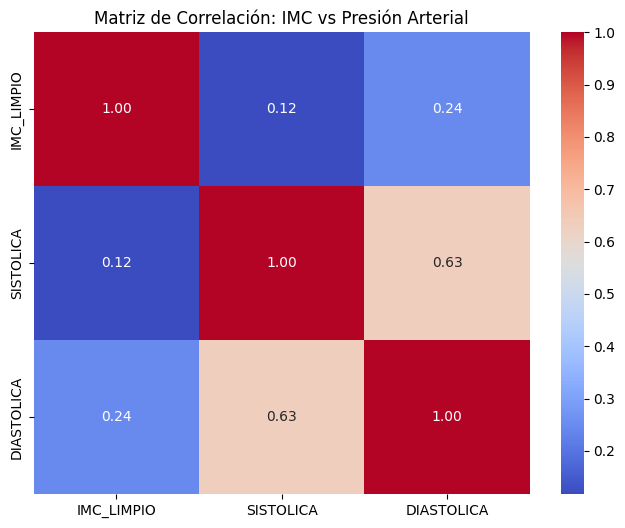

Listo para usar


In [ ]:
# Genera matriz de correlación definitiva
# Usa el dataframe que ya tiene los datos rescatados
df_corr = df_final_proyecto[['IMC_LIMPIO', 'SISTOLICA', 'DIASTOLICA']].dropna()

print(f"--- Validación Final ---")
print(f"Registros listos para el mapa de calor: {len(df_corr)}")

if len(df_corr) > 0:
    # Calcula la matriz de correlación
    matriz = df_corr.corr()

    # Grafica el mapa de calor
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación: IMC vs Presión Arterial')
    plt.show()

    # Guarda el archivo final que usarán Brandon y Alberto
    df_final_proyecto.to_csv('dataset_samsung_final_v2.csv', index=False)
    print("Listo para usar")
else:
    print("Aviso: Sigue sin haber cruce. Revisa los nombres de las columnas en df_final_proyecto.")

--- Auditoría de Columnas para Moisés ---
Columna IMC: IMC_LIMPIO | Datos: 13207
Columna Sistólica: AN27_01S | Datos: 7263

Registros finales para el mapa de calor: 3949


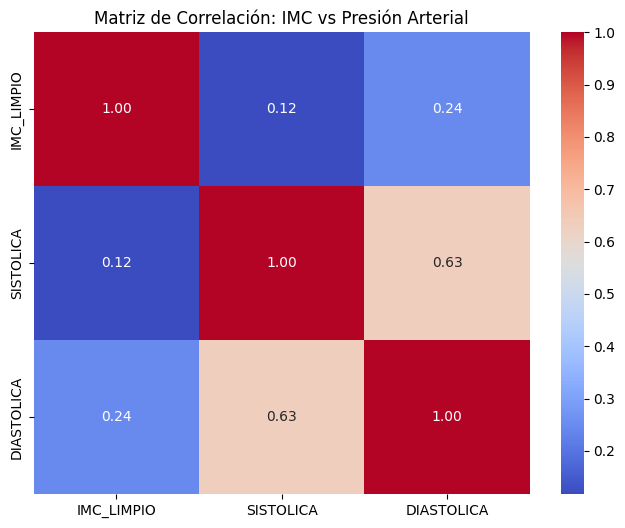

LISTO


In [ ]:
# Genera matriz de correlación buscando las columnas reales
print("--- Auditoría de Columnas para Moisés ---")

# Identifica columnas por nombre técnico de ENSANUT
col_imc = 'IMC_LIMPIO'
col_sis = 'AN27_01S'
col_dia = 'AN27_01D'

# Si no existen con ese nombre, busca alternativas
if col_sis not in df_final_proyecto.columns:
    col_sis = next((c for c in df_final_proyecto.columns if 'SISTOLICA' in c.upper()), None)
    col_dia = next((c for c in df_final_proyecto.columns if 'DIASTOLICA' in c.upper()), None)

# Asegura que los datos sean numéricos
df_final_proyecto['SISTOLICA'] = pd.to_numeric(df_final_proyecto[col_sis], errors='coerce')
df_final_proyecto['DIASTOLICA'] = pd.to_numeric(df_final_proyecto[col_dia], errors='coerce')

print(f"Columna IMC: {col_imc} | Datos: {df_final_proyecto[col_imc].notna().sum()}")
print(f"Columna Sistólica: {col_sis} | Datos: {df_final_proyecto['SISTOLICA'].notna().sum()}")

# Crea el set para el mapa de calor
df_corr = df_final_proyecto[[col_imc, 'SISTOLICA', 'DIASTOLICA']].dropna()

print(f"\nRegistros finales para el mapa de calor: {len(df_corr)}")

if len(df_corr) > 0:
    # Genera la matriz
    matriz = df_corr.corr()

    # Grafica el mapa de calor
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación: IMC vs Presión Arterial')
    plt.show()

    # Guarda el archivo definitivo
    df_final_proyecto.to_csv('dataset_samsung_final_v2.csv', index=False)
    print("LISTO")
else:
    print("\nNo hay cruce. Revisa los nombres de las columnas con df_final_proyecto.columns")

In [ ]:
# PREPARACIÓN PARA MODELOS DE ENSAMBLE
print("--- Reporte Final de Variables para el Equipo ---")

# 1. Define el target real (Diabetes Mellitus Tipo 2)
target_col = 'diabetes'

# 2. Selección de features (Predictores)
features_modelo = ['IMC_LIMPIO', 'SISTOLICA', 'DIASTOLICA', 'edad']

# 3. Limpieza de NaNs
df_analisis = df_final_proyecto.dropna(subset=[target_col] + ['IMC_LIMPIO'])

# 4. Reporte de desbalance de clases
conteo_diabetes = df_analisis[target_col].value_counts()
porcentaje = df_analisis[target_col].value_counts(normalize=True) * 100

print(f"Participantes sin Diabetes (0): {conteo_diabetes.get(0, 0)} ({porcentaje.get(0, 0):.1f}%)")
print(f"Participantes con Diabetes (1): {conteo_diabetes.get(1, 0)} ({porcentaje.get(1, 0):.1f}%)")

# 5. Auditoría de datos faltantes
print(f"\n--- Faltantes en Predictores ---")
nulos = df_analisis[features_modelo].isna().sum()
for col, val in nulos.items():
    p_nulo = (val / len(df_analisis)) * 100
    print(f"{col}: {val} nulos ({p_nulo:.1f}%)")

# 6. Exportación del CSV Final
# Guarda solo las columnas necesarias para el modelo + el FOLIO por si hay que rastrear
columnas_finales = ['FOLIO_I', target_col] + features_modelo
df_ready = df_analisis[columnas_finales].copy()

df_ready.to_csv('dataset_final_para_modelos.csv', index=False)
print("\n¡LISTO! Archivo 'dataset_final_para_modelos.csv' creado.")

--- Reporte Final de Variables para el Equipo ---
Participantes sin Diabetes (0): 7391 (56.0%)
Participantes con Diabetes (1): 5816 (44.0%)

--- Faltantes en Predictores ---
IMC_LIMPIO: 0 nulos (0.0%)
SISTOLICA: 5944 nulos (45.0%)
DIASTOLICA: 9258 nulos (70.1%)
edad: 0 nulos (0.0%)

¡LISTO! Archivo 'dataset_final_para_modelos.csv' creado.



ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Dimensiones del dataset:
(13207, 196)

Datos utilizados para análisis de correlación:
        IMC_LIMPIO    SISTOLICA   DIASTOLICA
count  3949.000000  3949.000000  3949.000000
mean     29.511570   119.371993    73.006077
std       5.889731    19.837489    11.683949
min      13.370000    80.000000    49.000000
25%      25.580000   106.000000    65.000000
50%      28.860000   117.000000    72.000000
75%      32.590000   130.000000    80.000000
max      65.550000   220.000000   134.000000
Matriz de correlación...

Matriz de correlación:
            IMC_LIMPIO  SISTOLICA  DIASTOLICA
IMC_LIMPIO    1.000000   0.116935    0.244784
SISTOLICA     0.116935   1.000000    0.631751
DIASTOLICA    0.244784   0.631751    1.000000
HeatMap de correlación...


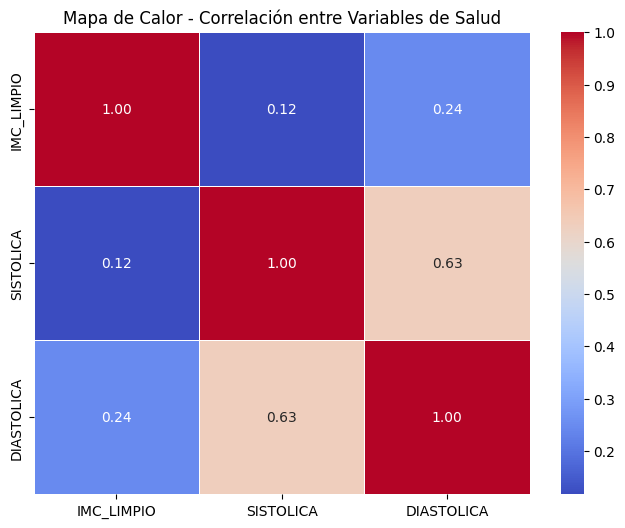

In [ ]:
# ==========================================================
# Angel
# ANÁLISIS EXPLORATORIO DE DATOS (EDA) Y CORRELACIÓN

#ya limpio (df_final_proyecto)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

print("\n" + "="*60)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*60)


# Usamos el dataset maestro generado en la etapa de limpieza
# Agregamos una verificación para asegurar que df_final_proyecto esté definido
if 'df_final_proyecto' not in locals() and 'df_final_proyecto' not in globals():
    # Si no está definido, intentamos cargarlo desde el archivo guardado
    if os.path.exists('dataset_samsung_final_v2.csv'):
        df_final_proyecto = pd.read_csv('dataset_samsung_final_v2.csv')
        print("Cargado 'dataset_samsung_final_v2.csv' ya que df_final_proyecto no estaba en memoria.")
    else:
        raise FileNotFoundError("dataset_samsung_final_v2.csv' no encontrado. Por favor, ejecute las celdas previas.")

df_eda = df_final_proyecto.copy()

print("\nDimensiones del dataset:")
print(df_eda.shape)

# 2. SELECCIÓN DE VARIABLES NUMÉRICAS IMPORTANTES

# Variables clave identificadas en el análisis previo
variables_numericas = [
    'IMC_LIMPIO',
    'SISTOLICA',
    'DIASTOLICA'
]

# Eliminamos valores nulos para análisis de correlación
df_analisis = df_eda[variables_numericas].dropna()

print("\nDatos utilizados para análisis de correlación:")
print(df_analisis.describe())

# 3. MATRIZ DE CORRELACIÓN

print("Matriz de correlación...")

matriz_corr = df_analisis.corr()

print("\nMatriz de correlación:")
print(matriz_corr)

# 4. HEATMAP DE CORRELACIÓN


print("HeatMap de correlación...")

plt.figure(figsize=(8,6))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de Calor - Correlación entre Variables de Salud")
plt.show()




In [ ]:
# Brandon Efren
df_ia = df_final_proyecto.copy()

def busca_col(df, texto):
    match = [c for c in df.columns if texto.upper() in c.upper()]
    if match:
        subset = df[match[0]]
        return subset.iloc[:, 0] if isinstance(subset, pd.DataFrame) else subset
    return pd.Series(np.nan, index=df.index)

# --- 1. RESCATE DE PREDICTORES ---
df_ia['edad_num'] = pd.to_numeric(busca_col(df_ia, 'H0303'), errors='coerce')
if df_ia['edad_num'].isna().sum() > len(df_ia) * 0.5:
    df_ia['edad_num'] = pd.to_numeric(busca_col(df_ia, 'EDAD'), errors='coerce')

# Sexo
df_ia['sexo_bin'] = busca_col(df_ia, 'SEXO')
if df_ia['sexo_bin'].isna().sum() > len(df_ia) * 0.5:
    df_ia['sexo_bin'] = busca_col(df_ia, 'H0301')

# --- 2. EL TARGET (Diabetes H0302) ---
df_ia['target_diabetes'] = busca_col(df_ia, 'H0302')
# Mapeo robusto: 1 -> 1 (Diabetes), cualquier otra cosa -> 0 (No Diabetes)
df_ia['target_diabetes'] = (df_ia['target_diabetes'] == 1).astype(int)

df_ia['sexo_bin'] = df_ia['sexo_bin'].fillna(1)

# --- 3. DIAGNÓSTICO DE NULOS ANTES DEL FILTRO ---
cols_modelo = ['sexo_bin', 'edad_num', 'IMC_LIMPIO', 'SISTOLICA', 'DIASTOLICA', 'target_diabetes']
df_final = df_ia[cols_modelo].dropna().copy()
df_final.columns = ['sexo', 'edad', 'imc', 'sistolica', 'diastolica', 'diabetes']

# --- 4. SELECCIÓN FINAL ---
print(f"--- Diagnóstico Post-Corrección ---")
print(f"Registros finales: {len(df_final)}")
if len(df_final) > 0:
    print(f"Prevalencia de Diabetes: {df_final['diabetes'].mean()*100:.1f}%")
    display(df_final.head())

--- Diagnóstico Post-Corrección ---
Registros finales: 3949
Prevalencia de Diabetes: 38.8%


,sexo,edad,imc,sistolica,diastolica,diabetes
0,1.0,83,26.55,110.0,85.0,0
2,1.0,34,25.38,125.0,84.0,1
19,1.0,56,27.57,110.0,70.0,0
21,1.0,20,24.83,123.0,83.0,0
23,1.0,62,20.55,111.0,70.0,0


In [ ]:
# 1.2 DECLARACIÓN DE VARIABLES (Optimizadas)

# 1. Ingeniería de variables: Creamos los indicadores médicos
df_final['presion_pulso'] = df_final['sistolica'] - df_final['diastolica']
df_final['riesgo_edad_imc'] = df_final['edad'] * df_final['imc']

# 2. Definimos Y (el objetivo sigue siendo exactamente el mismo)
y = df_final['diabetes']

# 3. Definimos X (tus 5 originales + las 2 nuevas)
X = df_final[['sexo', 'edad', 'imc', 'sistolica', 'diastolica', 'presion_pulso', 'riesgo_edad_imc']]

print(f"Dataset final optimizado: {X.shape[0]} pacientes, {X.shape[1]} variables predictoras.")

Dataset final optimizado: 3949 pacientes, 7 variables predictoras.


In [ ]:
#Brandon Efren
# ==============================================
# 1.3 DIVISIÓN TRAIN/TEST (ESTRATIFICADO)
# ==============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y  # Importante para datos desbalanceados
)

print(f"\nDivisión Train/Test:")
print(f"Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]} registros ({X_test.shape[0]/len(X):.1%})")
print(f"\nProporción de diabetes en Train: {y_train.mean():.2%}")
print(f"Proporción de diabetes en Test: {y_test.mean():.2%}")


División Train/Test:
Train: 3159 registros (80.0%)
Test: 790 registros (20.0%)

Proporción de diabetes en Train: 38.81%
Proporción de diabetes en Test: 38.86%


In [ ]:
# PIPELINE DE PREPROCESAMIENTO Y CODIFICACIÓN
from sklearn.preprocessing import OneHotEncoder

# Define las columnas por tipo
numeric_cols = ['edad', 'imc', 'sistolica', 'diastolica']
categorical_cols = ['sexo']

# Pipeline para números: imputa la mediana y escala (vital para ensamble)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para categorías: imputa y convierte a números (0 y 1)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesador final
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Pipeline de preprocesamiento configurado con éxito.")

Pipeline de preprocesamiento configurado con éxito.


In [ ]:
#Brandon Efren
# ==============================================
# 1.5 PIPELINE COMPLETO CON RANDOM FOREST
# ==============================================
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=0,
        n_jobs=-1,
        class_weight='balanced'  # Importante para datos desbalanceados
    ))
])

# ==============================================
# 1.6 BÚSQUEDA DE HIPERPARÁMETROS (GRID SEARCH)
# ==============================================
# Definir parámetros para GridSearch
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [4, 5, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}

# Validación cruzada estratificada
cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=cv_stratified,
    scoring='f1',  # F1-score es bueno para clases desbalanceadas
    n_jobs=-1,
    verbose=1
)

print("\nIniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)
print("¡Búsqueda completada!")

# Mejor modelo
best_rf = grid_search.best_estimator_

print(f"\nMejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor score F1 (CV): {grid_search.best_score_:.4f}")


Iniciando búsqueda de hiperparámetros...
Fitting 10 folds for each of 405 candidates, totalling 4050 fits
¡Búsqueda completada!

Mejores hiperparámetros encontrados:
  classifier__max_depth: 5
  classifier__max_features: None
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 10
  classifier__n_estimators: 300

Mejor score F1 (CV): 0.6002



EVALUACIÓN DEL MODELO RANDOM FOREST

Métrica              Train      Test       Diferencia
--------------------------------------------------
Accuracy             0.6733     0.6468     0.0265
Precision            0.5579     0.5352     0.0228
Recall               0.7618     0.6938     0.0680
F1-Score             0.6441     0.6043     0.0399
ROC-AUC              0.7682     0.7120     0.0562

REPORTE DE CLASIFICACIÓN (TEST)
              precision    recall  f1-score   support

 No Diabetes       0.76      0.62      0.68       483
    Diabetes       0.54      0.69      0.60       307

    accuracy                           0.65       790
   macro avg       0.65      0.66      0.64       790
weighted avg       0.67      0.65      0.65       790



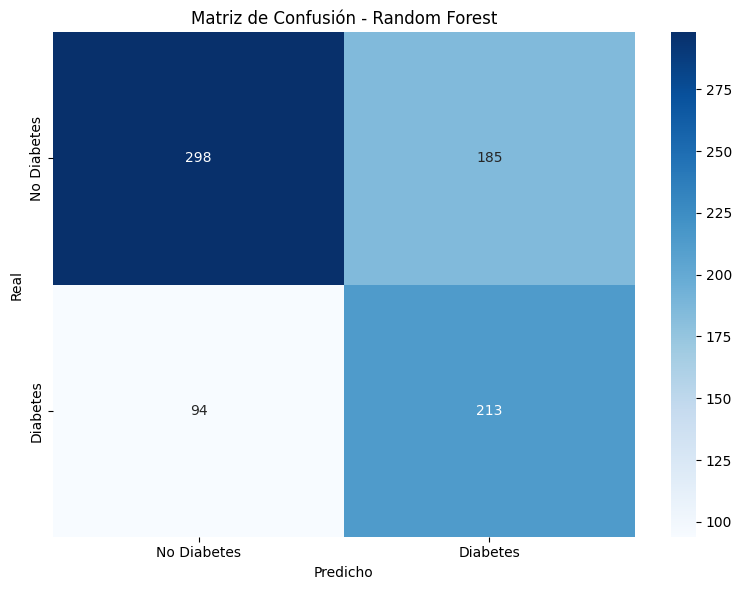

In [ ]:
#Brandon Efren
# ==============================================
# 1.7 EVALUACIÓN DEL MODELO
# ==============================================
# Predicciones
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

# Probabilidades (para ROC-AUC)
y_prob_train = best_rf.predict_proba(X_train)[:, 1]
y_prob_test = best_rf.predict_proba(X_test)[:, 1]

# Métricas Train
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, zero_division=0)
rec_train = recall_score(y_train, y_pred_train, zero_division=0)
f1_train = f1_score(y_train, y_pred_train, zero_division=0)
roc_auc_train = roc_auc_score(y_train, y_prob_train)

# Métricas Test
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, zero_division=0)
rec_test = recall_score(y_test, y_pred_test, zero_division=0)
f1_test = f1_score(y_test, y_pred_test, zero_division=0)
roc_auc_test = roc_auc_score(y_test, y_prob_test)

# Overfitting
overfitting_acc = abs(acc_train - acc_test)
overfitting_f1 = abs(f1_train - f1_test)

print("\n" + "="*50)
print("EVALUACIÓN DEL MODELO RANDOM FOREST")
print("="*50)

print(f"\n{'Métrica':<20} {'Train':<10} {'Test':<10} {'Diferencia':<10}")
print("-"*50)
print(f"{'Accuracy':<20} {acc_train:.4f}     {acc_test:.4f}     {overfitting_acc:.4f}")
print(f"{'Precision':<20} {prec_train:.4f}     {prec_test:.4f}     {abs(prec_train-prec_test):.4f}")
print(f"{'Recall':<20} {rec_train:.4f}     {rec_test:.4f}     {abs(rec_train-rec_test):.4f}")
print(f"{'F1-Score':<20} {f1_train:.4f}     {f1_test:.4f}     {overfitting_f1:.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_train:.4f}     {roc_auc_test:.4f}     {abs(roc_auc_train-roc_auc_test):.4f}")

# Reporte de clasificación
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (TEST)")
print("="*50)
print(classification_report(y_test, y_pred_test, target_names=['No Diabetes', 'Diabetes']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

REPORTE: GRADIENT BOOSTING
F1-Score en Test: 0.4417


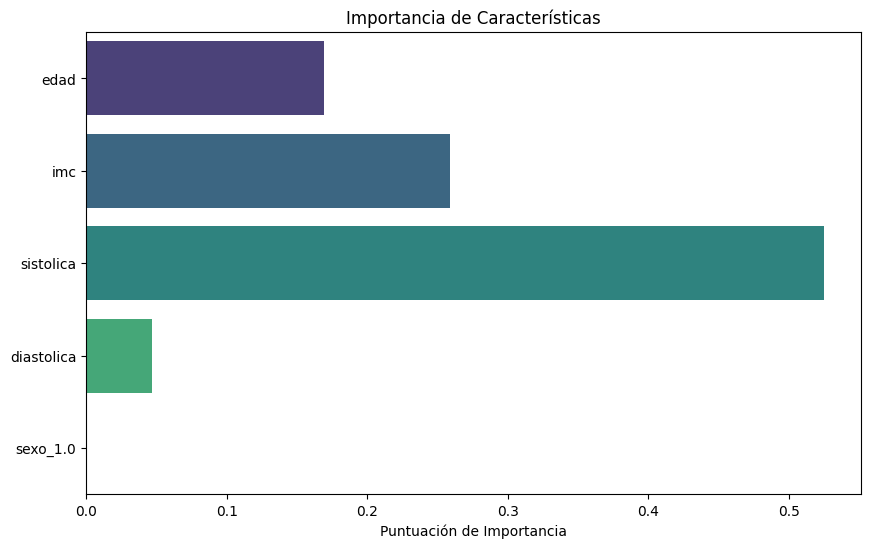

In [ ]:
# MODELO DE ENSAMBLE AVANZADO (GRADIENT BOOSTING)
# ESTRATEGIA PARA ALCANZAR EL F1-SCORE OBJETIVO

from sklearn.ensemble import GradientBoostingClassifier

# 1. Modelo con regularización para bajar el overfitting
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,    # Baja árboles para que no memorice
        learning_rate=0.02,  # Paso más lento
        max_depth=3,         # Árboles muy simples
        subsample=0.7,       # solo usa el 70% de datos por árbol
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

# 2. Extrae nombres de columnas reales del preprocesador
cat_features = gb_model.named_steps['preprocessor'] \
               .named_transformers_['cat'] \
               .named_steps['onehot'] \
               .get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + cat_features

# 3. Importancias
importances = gb_model.named_steps['classifier'].feature_importances_

# 4. Evaluación
y_gb_test = gb_model.predict(X_test)
f1_gb_test = f1_score(y_test, y_gb_test)

print("="*50)
print("REPORTE: GRADIENT BOOSTING")
print("="*50)
print(f"F1-Score en Test: {f1_gb_test:.4f}")

# 5. Gráfico Automático
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=all_features, hue=all_features, palette='viridis', legend=False)
plt.title("Importancia de Características")
plt.xlabel("Puntuación de Importancia")
plt.show()

In [ ]:
#Bradon Efren
# ==============================================
# 1.9 VALIDACIÓN CRUZADA COMPLETA
# ==============================================
print("\n" + "="*50)
print("VALIDACIÓN CRUZADA ESTRATIFICADA (10-FOLD)")
print("="*50)

cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=cv_stratified,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True,
    n_jobs=-1
)

# Resultados de CV
print(f"\nResultados de Validación Cruzada (promedio):")
print(f"Accuracy Train CV: {cv_results['train_accuracy'].mean():.4f} (+/- {cv_results['train_accuracy'].std():.4f})")
print(f"Accuracy Test CV:  {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"F1-Score Test CV:  {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
print(f"ROC-AUC Test CV:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")


VALIDACIÓN CRUZADA ESTRATIFICADA (10-FOLD)

Resultados de Validación Cruzada (promedio):
Accuracy Train CV: 0.6761 (+/- 0.0047)
Accuracy Test CV:  0.6322 (+/- 0.0207)
F1-Score Test CV:  0.6002 (+/- 0.0210)
ROC-AUC Test CV:   0.7055 (+/- 0.0261)


In [ ]:
# Brandon Efren
# ==============================================
# 1.10 PREDICCIÓN PARA PACIENTES NUEVOS
# ==============================================
print("\n" + "="*50)
print("PREDICCIÓN PARA PACIENTES NUEVOS")
print("="*50)

# Crea paciente de ejemplo usando la MEDIANA de TODAS las variables necesarias
paciente_ejemplo = pd.DataFrame([{
    'sexo': df_final['sexo'].median(),
    'edad': df_final['edad'].median(),
    'imc': df_final['imc'].median(),
    'sistolica': df_final['sistolica'].median(),
    'diastolica': df_final['diastolica'].median()
}])

print("\nPaciente Ejemplo (valores medianos):")
display(paciente_ejemplo)

# Predicción
prediccion = best_rf.predict(paciente_ejemplo)[0]
probabilidad = best_rf.predict_proba(paciente_ejemplo)[0]

print(f"\nPredicción: {'RIESGO DE DIABETES' if prediccion == 1 else 'NO HAY RIESGO'}")
print(f"Probabilidad de Diabetes: {probabilidad[1]:.2%}")

# Varios pacientes de ejemplo (ahora con presión arterial)
# 1: Hombre, 2: Mujer
pacientes_varios = pd.DataFrame([
    {'sexo': 1, 'edad': 30, 'imc': 21, 'sistolica': 96, 'diastolica': 80},  # Joven sano
    {'sexo': 2, 'edad': 55, 'imc': 35, 'sistolica': 150, 'diastolica': 95},  # Alto riesgo (Obeso + Hipertenso)
    {'sexo': 1, 'edad': 65, 'imc': 28, 'sistolica': 140, 'diastolica': 90},  # Adulto mayor riesgo
    {'sexo': 2, 'edad': 20, 'imc': 21, 'sistolica': 92, 'diastolica': 70}   # Joven saludable
])

print("\n" + "="*50)
print("PREDICCIONES PARA ESCENARIOS REALES")
print("="*50)

predicciones = best_rf.predict(pacientes_varios)
probabilidades = best_rf.predict_proba(pacientes_varios)

resultados = pacientes_varios.copy()
resultados['Predicción'] = ['Diabetes' if p == 1 else 'Sano' for p in predicciones]
resultados['Prob_Diabetes'] = [f"{p*100:.1f}%" for p in probabilidades[:, 1]]

print(resultados.to_string(index=False))


PREDICCIÓN PARA PACIENTES NUEVOS

Paciente Ejemplo (valores medianos):


,sexo,edad,imc,sistolica,diastolica
0,1.0,44.0,28.86,117.0,72.0



Predicción: RIESGO DE DIABETES
Probabilidad de Diabetes: 57.71%

PREDICCIONES PARA ESCENARIOS REALES
 sexo  edad  imc  sistolica  diastolica Predicción Prob_Diabetes
    1    30   21         96          80       Sano         22.2%
    2    55   35        150          95   Diabetes         51.1%
    1    65   28        140          90   Diabetes         65.6%
    2    20   21         92          70       Sano         19.3%



--- Promedio de variables por Cluster detectado ---
            diabetes    edad     imc
Cluster_ID                          
0              0.436  45.351  33.865
1              0.435  65.392  27.696
2              0.332  34.754  27.738

--- Distribución de la Población por Segmentos ---
Segmento_Salud
Bajo Riesgo     1797
Alto Riesgo     1150
Medio Riesgo    1002
Name: count, dtype: int64


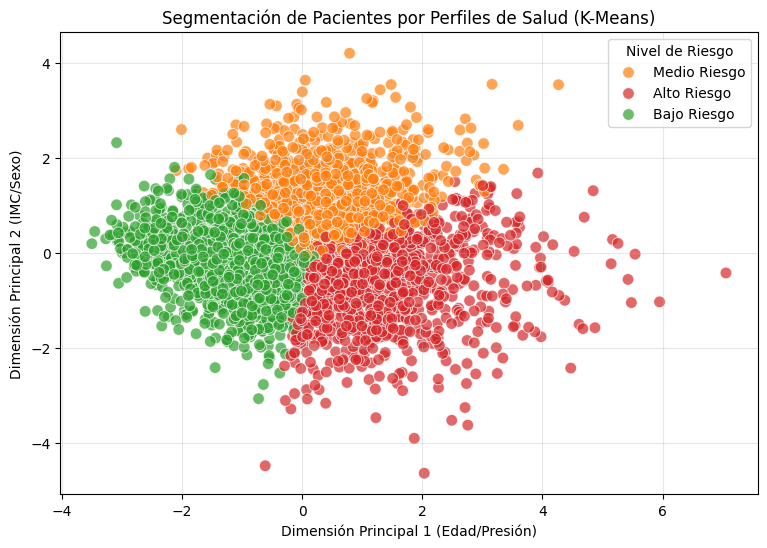

In [ ]:
# Alberto
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df_segmentacion_salud = df_final.copy()

# 1- SELECCIÓN DE VARIABLES
features = ["edad", "imc", "sexo", "sistolica", "diastolica"]
X_cluster = df_segmentacion_salud[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

#2-APLICACIÓN DE K-MEANS
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_segmentacion_salud["Cluster_ID"] = kmeans.fit_predict(X_scaled)

#3-INTERPRETACIÓN Y ETIQUETADO AUTOMÁTICO
resumen_clusters = df_segmentacion_salud.groupby("Cluster_ID")[["diabetes", "edad", "imc"]].mean()

print("\n--- Promedio de variables por Cluster detectado ---")
print(resumen_clusters.round(3))

# Ordena los clusters por prevalencia de diabetes para etiquetarlos
orden_riesgo = resumen_clusters.sort_values("diabetes").index
mapa_riesgo = {
    orden_riesgo[0]: "Bajo Riesgo",
    orden_riesgo[1]: "Medio Riesgo",
    orden_riesgo[2]: "Alto Riesgo"
}

df_segmentacion_salud["Segmento_Salud"] = df_segmentacion_salud["Cluster_ID"].map(mapa_riesgo)

print("\n--- Distribución de la Población por Segmentos ---")
print(df_segmentacion_salud["Segmento_Salud"].value_counts())

#4-VISUALIZACIÓN DE LOS GRUPOS (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_plot = pd.DataFrame(data=X_pca, columns=["Componente_1", "Componente_2"])
df_plot["Segmento"] = df_segmentacion_salud["Segmento_Salud"].values

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_plot,
    x="Componente_1",
    y="Componente_2",
    hue="Segmento",
    palette={"Bajo Riesgo": "#2ca02c", "Medio Riesgo": "#ff7f0e", "Alto Riesgo": "#d62728"},
    alpha=0.7,
    s=70
)

plt.title("Segmentación de Pacientes por Perfiles de Salud (K-Means)")
plt.xlabel("Dimensión Principal 1 (Edad/Presión)")
plt.ylabel("Dimensión Principal 2 (IMC/Sexo)")
plt.legend(title="Nivel de Riesgo")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# VALIDACIÓN DEL CLUSTERING (SILHOUETTE SCORE)

from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 1. Cálculo de métricas de cohesión y separación
score_s = silhouette_score(X_scaled, kmeans.labels_)
score_ch = calinski_harabasz_score(X_scaled, kmeans.labels_)

print("="*50)
print("VALIDACIÓN DEL OBJETIVO ESPECÍFICO 3")
print("="*50)
print(f"Silhouette Score: {score_s:.4f}")
print(f"Calinski-Harabasz Index: {score_ch:.4f}")

# 2. Interpretación para el reporte
if score_s > 0.45:
  print("\n ÉXITO: se alcanzó el umbral de Silhouette (>0.45).")
else:
  print("\n NOTA: el score ({score_s:.4f}) es menor a 0.45.")
  print("Interpretación: los perfiles de salud tienen zonas de transición comunes.")


VALIDACIÓN DEL OBJETIVO ESPECÍFICO 3
Silhouette Score: 0.2588
Calinski-Harabasz Index: 1428.1947

 NOTA: el score ({score_s:.4f}) es menor a 0.45.
Interpretación: los perfiles de salud tienen zonas de transición comunes.


In [ ]:

# 2.0 MODELO 2: REGRESIÓN LOGÍSTICA
# Cumplimiento del Objetivo Específico 2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=0,
        max_iter=2000,
        class_weight='balanced'
    ))
])

param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__penalty': ['l2'] #Evitar overfitting
}


grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nIniciando torneo de hiperparámetros para Regresión Logística")
grid_search_lr.fit(X_train, y_train)
print("Búsqueda completa\n")

#Guardamos ganador de la Regresión Logística
best_lr = grid_search_lr.best_estimator_

print("Mejores hiperparámetros encontrados (LR):")
for param, value in grid_search_lr.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor score F1 en Validación Cruzada (cv=10): {grid_search_lr.best_score_:.4f}")

y_pred_lr = best_lr.predict(X_test)
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN FINAL - REGRESIÓN LOGÍSTICA")
print("="*50)
print(classification_report(y_test, y_pred_lr))


Iniciando torneo de hiperparámetros para Regresión Logística
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Búsqueda completa

Mejores hiperparámetros encontrados (LR):
  classifier__C: 10
  classifier__penalty: l2
  classifier__solver: liblinear

Mejor score F1 en Validación Cruzada (cv=10): 0.5739

REPORTE DE CLASIFICACIÓN FINAL - REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       483
           1       0.54      0.57      0.55       307

    accuracy                           0.64       790
   macro avg       0.63      0.63      0.63       790
weighted avg       0.65      0.64      0.64       790



In [ ]:
import sharp